# HEART DISEASE (CLASSIFICATION PROBLEM)

## 1. Problem Definition 

> Cardiovascular diseases are among the leading causes of mortality worldwide, which makes early detection and risk assessment extremely important. In this project, I aim to develop a classification model capable of predicting the presence of heart disease in a patient based on relevant clinical attributes. I formulate this as a binary classification problem, where my objective is to assign each patient to one of two classes: presence or absence of heart disease.

## 2. Data 

In this study, I use a dataset that dates back to 1988 and combines information from four different databases: Cleveland, Hungary, Switzerland, and Long Beach V. The dataset contains a total of 76 attributes, including the target variable. However, I focus on a subset of 14 features, as these are the most commonly used in previous studies and are considered the most relevant for prediction. The target variable indicates the presence of heart disease in a patient and is encoded as follows:
* 0: no heart disease
* 1: heart disease present

> The original dataset originates from the Cleveland database, part of the UCI Machine Learning Repository: https://archive.ics.uci.edu/dataset/45/heart+disease

> The dataset is available for viewing and download on Kaggle via the following link: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

## 3. Evaluation

> The project will be considered successful if the developed model achieves an accuracy of at least 83% in correctly classifying the presence of heart disease based on clinical indicators.

## 4. Features 

**Data dictionary**

1. age (in years)
2. sex (1=male; 0=female)
3. chest pain type (4 values)
   * 0: Typical angina: chest pain related decrease blood supply to the heart
   * 1: Atypical angina: chest pain not related to heart
   * 2: Non-anginal pain: typically esophageal spasms (non heart related)
   * 3: Asymptomatic: chest pain not showing signs of disease
4. trestbps = resting blood pressure (in mm Hg on admission to the hospital)
   * anything above 130-140 is typically cause for concern
5. chol = serum cholestoral in mg/dl
   * serum = LDL + HDL + .2 * triglycerides
   * above 200 is cause for concern
6. fbs = fasting blood sugar > 120 mg/dl (1=true, 0=false)
   * '>126' mg/dL signals diabetes
7. restecg = resting electrocardiographic results (values 0,1,2):
   * 0: Nothing to note
   * 1: ST-T Wave abnormality
     * can range from mild symptoms to severe problems
     * signals non-normal heart beat
   * 2: Possible or definite left ventricular hypertrophy
     * Enlarged heart's main pumping chamber
8. thalach = maximum heart rate achieved
9. exang = exercise induced angina (1 = yes; 0 = no)
10. oldpeak = ST depression induced by exercise relative to rest
11. slope = the slope of the peak exercise ST segment
    * 0: Upsloping -> better heart rate with exercise (uncommon)
    * 1: Flatsloping -> minimal change (typical healthy heart)
    * 2: Downsloping -> signs of unhealthy heart
12. ca = number of major vessels (0-3) colored by fluoroscopy
    * the more blood movement the better (no clots)
    * colored vessel means the doctor can see the blood passing through
13. thal = thallium stress result:
    * 0 = normal
    * 1 = fixed defect
    * 2 = reversable defect -> no proper blood movement when exercising
14. target - have disease or not (1=yes, 0=no)
> Note: The names and social security numbers of the patients were recently removed from the database, replaced with dummy values.

# Data Loading

In [1]:
# Tools

# EDA & plotting libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline 

# Models from Scikit-Learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV 
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, roc_curve, auc


In [2]:
df = pd.read_csv("heart.csv")
df.shape

(1025, 14)

# Data Cleaning

In [3]:
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [4]:
df.tail(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1015,58,1,0,128,216,0,0,131,1,2.2,1,3,3,0
1016,65,1,3,138,282,1,0,174,0,1.4,1,1,2,0
1017,53,1,0,123,282,0,1,95,1,2.0,1,2,3,0
1018,41,1,0,110,172,0,0,158,0,0.0,2,0,3,0
1019,47,1,0,112,204,0,1,143,0,0.1,2,0,2,1
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [5]:
df["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

## Data Types and Missing Values Analysis

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

The imported dataset does not contain any missing values, and the data types are correctly defined, with most variables being of type int64, except for oldpeak, which is of type float64. Therefore, the data types do not pose any issues for training the chosen model.

In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


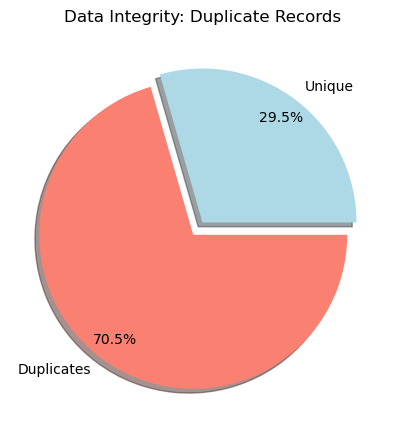

In [9]:
counts = [len(df) - df.duplicated().sum(), df.duplicated().sum()]

fig, ax = plt.subplots(figsize=(5, 5))

ax.pie(
    counts, 
    labels=["Unique", "Duplicates"],
    colors=["lightblue", "salmon"],
    autopct="%1.1f%%",
    startangle=0,
    explode=(0, 0.1),
    shadow=True,
    pctdistance=0.85
)
ax.set_title("Data Integrity: Duplicate Records")
plt.show()

In [10]:
df.duplicated().value_counts()

True     723
False    302
Name: count, dtype: int64

In [11]:
len(df)

1025

Based on initial checks, the loaded dataset contains 1025 rows, of which 723 are duplicates. Percentage-wise, duplicates account for 70.5% of the data, while the remaining 29.5% are unique records.

In [12]:
diff_target = [c for c in df.columns if c != "target"]
suspicious = df[df.duplicated(subset=diff_target, keep=False)]
conflicts = suspicious.groupby(diff_target)["target"].nunique()
print(f"Identical features with different target {(conflicts > 1).sum()}")

Identical features with different target 0


In [13]:
df_clean = df.drop_duplicates()
df_clean.duplicated().value_counts()

False    302
Name: count, dtype: int64

The dataset contains 1025 rows, of which 723 are exact duplicates (same patient, same values). Since no duplicates with a contradictory target were found, the repeated rows add no real information and can cause data leakage between the train and test sets. After removal, 302 unique rows remain.

# EDA

## Distribution of Heart Disease Cases

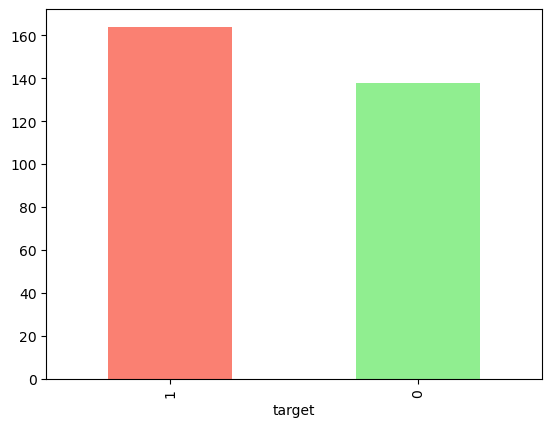

In [14]:
df_clean["target"].value_counts().plot(kind="bar", color=["salmon", "lightgreen"]);

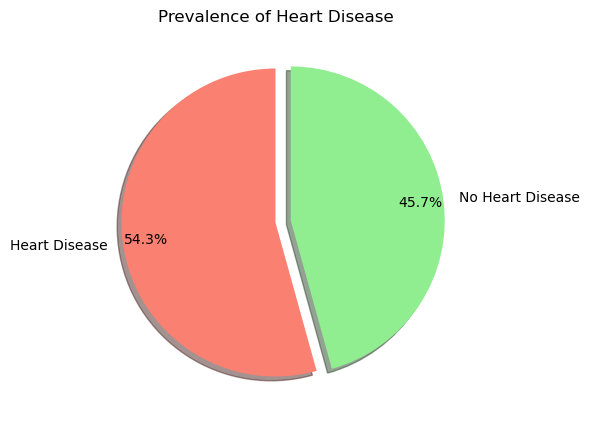

In [15]:
counts = df_clean["target"].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))

ax.pie(
    counts,
    labels=["Heart Disease", "No Heart Disease"],
    colors=["salmon", "lightgreen"],
    autopct="%1.1f%%",
    startangle=90,
    explode=(0,0.1),
    shadow=True,
    pctdistance=0.85
)

ax.set_title("Prevalence of Heart Disease")
plt.show()

In [16]:
df_clean["target"].value_counts()

target
1    164
0    138
Name: count, dtype: int64

The cleaned dataset contains 164 patients diagnosed with heart disease (target = 1) 
and 138 without (target = 0), yielding a near-balanced class distribution of roughly 
54.3% to 45.7%. This balance is advantageous for training classification models, as it 
minimizes the risk of bias toward the majority class and reduces the need for 
resampling techniques such as SMOTE or class weighting.

## Data Types and Missing Values Analysis

In [17]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [18]:
df_clean.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [19]:
df_clean.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Distribution of Heart Disease Cases by Gender

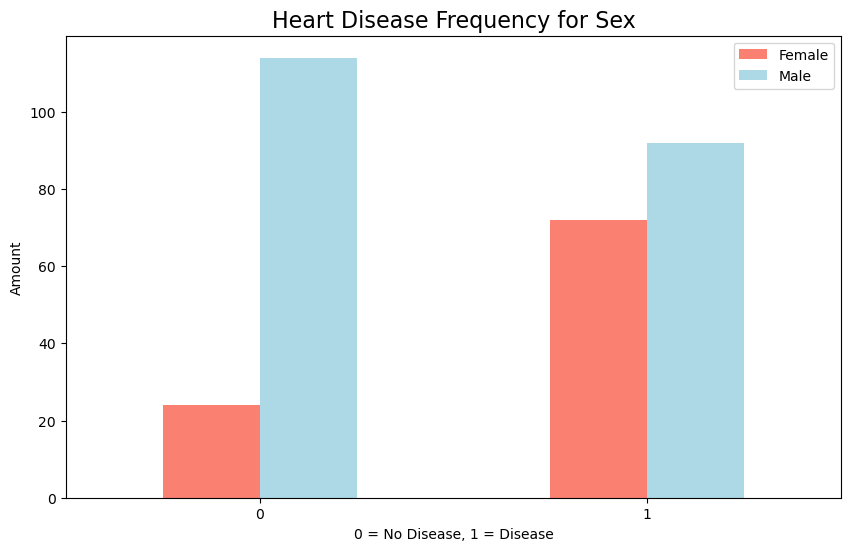

In [20]:
pd.crosstab(df_clean.target, df_clean.sex).plot(kind="bar",
                                                figsize=(10, 6),
                                                color=["salmon", "lightblue"])
plt.title("Heart Disease Frequency for Sex", fontsize=16)
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Amount")
plt.legend(["Female", "Male"])
plt.xticks(rotation=0);

In [21]:
df_clean.sex.value_counts()

sex
1    206
0     96
Name: count, dtype: int64

In [22]:
pd.crosstab(df_clean.target, df_clean.sex)

sex,0,1
target,,
0,24,114
1,72,92


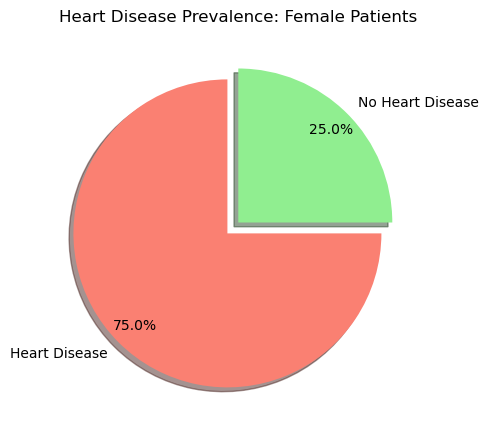

In [23]:
females_heart_disease = df_clean.groupby(["sex", "target"]).size()[0, 1]
counts = [df_clean.sex.value_counts()[0] - females_heart_disease, females_heart_disease]

fig, ax = plt.subplots(figsize=(5, 5))

ax.pie(
    counts,
    labels=["No Heart Disease", "Heart Disease"],
    colors=["lightgreen", "salmon"],
    autopct="%1.1f%%",
    startangle=0,
    explode=(0, 0.1),
    shadow=True,
    pctdistance=0.85
)

ax.set_title("Heart Disease Prevalence: Female Patients")
plt.show()

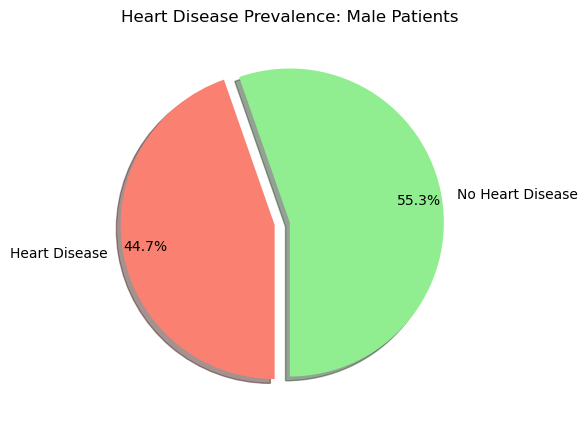

In [24]:
males_heart_disease = df_clean.groupby(["sex", "target"]).size()[1, 1]
counts = [df_clean.sex.value_counts()[1] - males_heart_disease, males_heart_disease]

fig, ax = plt.subplots(figsize=(5, 5))

ax.pie(
    counts,
    labels=["No Heart Disease", "Heart Disease"],
    colors=["lightgreen", "salmon"],
    autopct="%1.1f%%",
    startangle=270,
    explode=(0, 0.1),
    shadow=True,
    pctdistance=0.85
)

ax.set_title("Heart Disease Prevalence: Male Patients")
plt.show()

Among female patients (sex = 0), 72 out of 96 (75%) were diagnosed with heart disease, 
compared to 92 out of 206 males (44.7%). Despite males comprising the majority of the 
dataset, females show a disproportionately higher rate of positive diagnoses within 
this sample (3:1 ratio of positive to negative cases among females).

## Relationship Between Age and Maximum Heart Rate by Disease Status

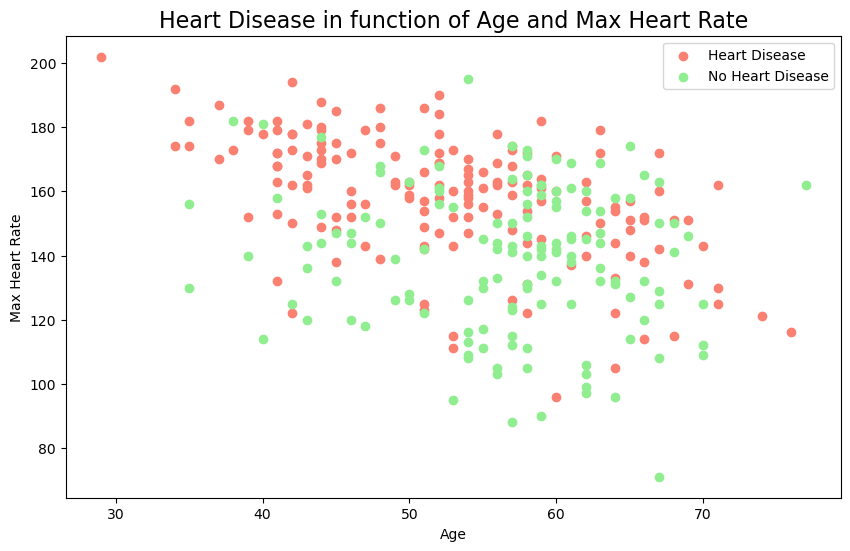

In [81]:
plt.figure(figsize=(10, 6))

# Scatter with positive examples - with heart disease
plt.scatter(df_clean.age[df_clean.target==1], df_clean.thalach[df_clean.target==1], c="salmon")

# Scatter with negative examples - without heart disease
plt.scatter(df_clean.age[df_clean.target==0], df_clean.thalach[df_clean.target==0], c="lightgreen")
plt.title("Heart Disease in function of Age and Max Heart Rate", fontsize=16)
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.legend(["Heart Disease", "No Heart Disease"]);
plt.show();

The scatter plot reveals a visible inverse trend between age and maximum heart rate (thalach): as age increases, the maximum heart rate tends to decrease, suggesting that older individuals may be less exposed to heart disease risk in this context. It is worth noting that among patients with heart disease (shown in salmon), the younger individuals reach the highest maximum heart rate values, while those without the disease (shown in light blue) are generally older and exhibit lower peak rates. The majority of patients are between 45 and 65 years old, confirming that middle-aged individuals represent the core demographic of this dataset.

## Age Distribution Analysis

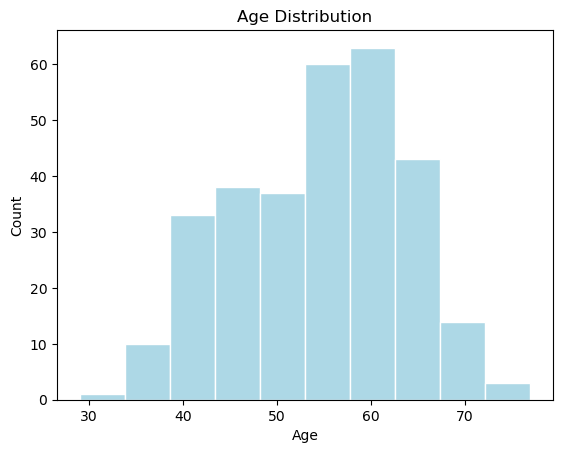

In [82]:
df_clean.age.plot.hist(title="Age Distribution", color="lightblue", edgecolor="white")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show();

## Heart Disease Frequency per Chest Pain Type 

3 cp: chest pain type
* 0: typical angina
* 1: atypical angina
* 2: non-anginal pain
* 3: asymptomatic

In [27]:
pd.crosstab(df_clean.cp, df_clean.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,68
3,7,16


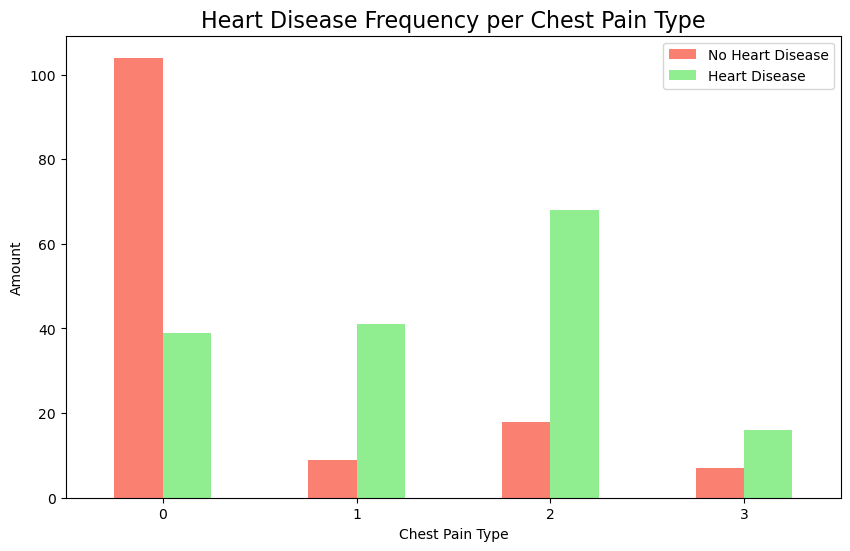

In [28]:
pd.crosstab(df_clean.cp, df_clean.target).plot(kind="bar", figsize=(10, 6), 
                                               color=["salmon", "lightgreen"])
plt.title("Heart Disease Frequency per Chest Pain Type", fontsize=16)
plt.xlabel("Chest Pain Type")
plt.ylabel("Amount")
plt.legend(["No Heart Disease", "Heart Disease"])
plt.xticks(rotation=0);

Chest pain type 0 (typical angina) is overwhelmingly associated with the absence of heart disease (104 negative vs. 39 positive cases), whereas types 1, 2, and 3 all show a higher proportion of positive diagnoses. Specifically, type 2 (non-anginal pain) accounts for 68 disease cases compared to 18 healthy ones. Conversely, asymptomatic pain (type 3) and atypical angina (type 1) possess a higher predictive value for the presence of the disease than typical angina. This highlights the importance of chest pain type as a highly informative feature for the model.

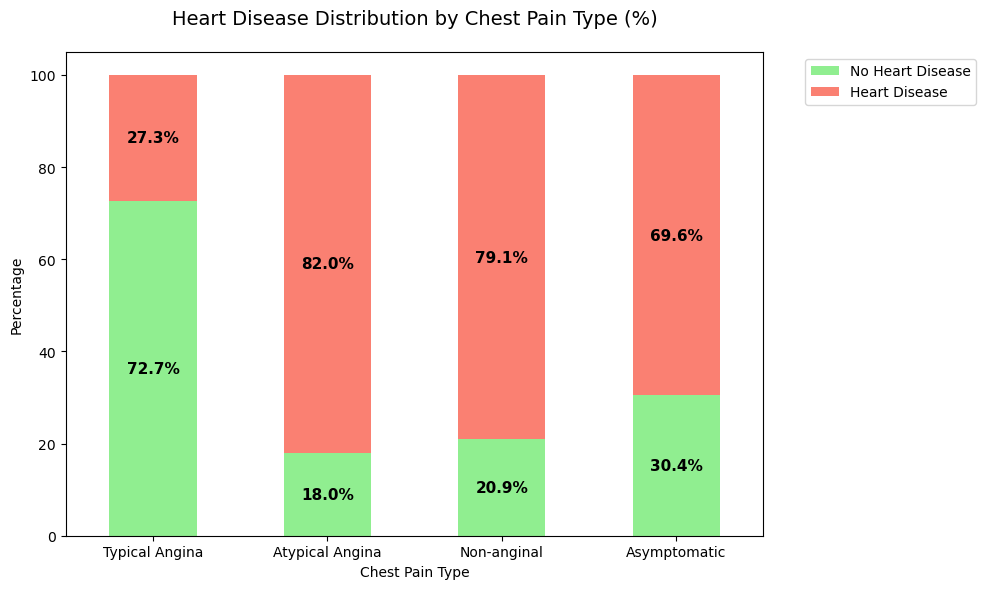

In [29]:
ct = pd.crosstab(df_clean['cp'], df_clean['target'])
ct.index = ['Typical Angina', 'Atypical Angina', 'Non-anginal', 'Asymptomatic']
ct.columns = ['No Heart Disease', 'Heart Disease']

ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

ax = ct_pct.plot(kind='bar', 
                 stacked=True, 
                 figsize=(10, 6), 
                 color=["lightgreen", "salmon"],
                 rot=0) 

for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy() 
    
    if height > 0:
        ax.annotate(f'{height:.1f}%', 
                    (x + width/2, y + height/2), 
                    ha='center', 
                    va='center',
                    fontsize=11,
                    fontweight='bold',
                    color='black')


plt.title("Heart Disease Distribution by Chest Pain Type (%)", pad=20, fontsize=14)
plt.xlabel("Chest Pain Type")
plt.ylabel("Percentage")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

The stacked percentage chart offers a normalized view of disease prevalence across chest pain categories, revealing striking differences in risk profiles. Typical angina (cp = 0) is predominantly benign, with 72.7% of patients in this group showing no signs of disease.

In contrast, atypical angina (cp = 1) and non-anginal pain (cp = 2) are associated with the presence of disease in 82% and 79.1% of cases, respectively. Similarly, asymptomatic pain (cp = 3) shows a majority of disease cases at 69.6%.

This analysis suggests that the occurrence of chest pain (specifically atypical angina, non-anginal, and asymptomatic types) strongly indicates the presence of heart disease, thereby confirming that the type of chest pain is one of the most informative features in the dataset.

In [30]:
df_clean.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.094962,-0.063107,0.283121,0.207216,0.119492,-0.111590,-0.395235,0.093216,0.206040,-0.164124,0.302261,0.065317,-0.221476
sex,-0.094962,1.000000,-0.051740,-0.057647,-0.195571,0.046022,-0.060351,-0.046439,0.143460,0.098322,-0.032990,0.113060,0.211452,-0.283609
cp,-0.063107,-0.051740,1.000000,0.046486,-0.072682,0.096018,0.041561,0.293367,-0.392937,-0.146692,0.116854,-0.195356,-0.160370,0.432080
trestbps,0.283121,-0.057647,0.046486,1.000000,0.125256,0.178125,-0.115367,-0.048023,0.068526,0.194600,-0.122873,0.099248,0.062870,-0.146269
chol,0.207216,-0.195571,-0.072682,0.125256,1.000000,0.011428,-0.147602,-0.005308,0.064099,0.050086,0.000417,0.086878,0.096810,-0.081437
fbs,0.119492,0.046022,0.096018,0.178125,0.011428,1.000000,-0.083081,-0.007169,0.024729,0.004514,-0.058654,0.144935,-0.032752,-0.026826
restecg,-0.111590,-0.060351,0.041561,-0.115367,-0.147602,-0.083081,1.000000,0.041210,-0.068807,-0.056251,0.090402,-0.083112,-0.010473,0.134874
thalach,-0.395235,-0.046439,0.293367,-0.048023,-0.005308,-0.007169,0.041210,1.000000,-0.377411,-0.342201,0.384754,-0.228311,-0.094910,0.419955
exang,0.093216,0.143460,-0.392937,0.068526,0.064099,0.024729,-0.068807,-0.377411,1.000000,0.286766,-0.256106,0.125377,0.205826,-0.435601
oldpeak,0.206040,0.098322,-0.146692,0.194600,0.050086,0.004514,-0.056251,-0.342201,0.286766,1.000000,-0.576314,0.236560,0.209090,-0.429146


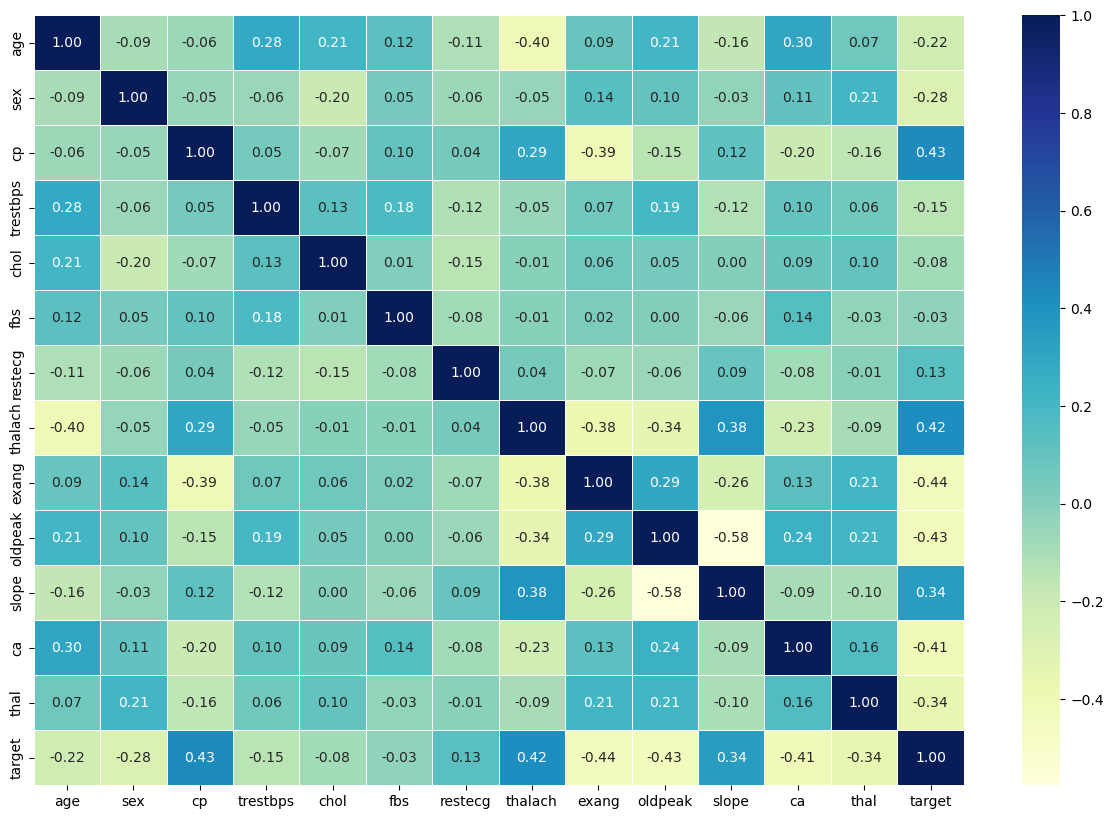

In [31]:
corr_matrix = df_clean.corr()
fig, ax = plt.subplots(figsize=(15, 10))
ax = sns.heatmap(corr_matrix, annot=True, linewidths=0.5, fmt=".2f", cmap="YlGnBu")

The correlation matrix reveals several noteworthy relationships with the target variable. 
Chest pain type (cp), maximum heart rate (thalach), and slope of the ST segment show 
moderate positive correlations with heart disease presence, while exercise-induced 
angina (exang), ST depression (oldpeak), and the number of major vessels coloured 
by fluoroscopy (ca) exhibit moderate negative correlations. Features such as resting 
blood pressure (trestbps) and fasting blood sugar (fbs) show weak associations with 
the target, suggesting limited individual predictive power. 

# 5. Modeling 

In [32]:
df_clean.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Train Test Split

In [33]:
X = df_clean.drop("target", axis=1)
y = df_clean["target"]

In [34]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2


In [35]:
y

0      0
1      0
2      0
3      0
4      0
      ..
723    1
733    1
739    0
843    0
878    0
Name: target, Length: 302, dtype: int64

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
X_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
163,48,1,0,124,274,0,0,166,0,0.5,1,0,3
291,58,1,0,128,259,0,0,130,1,3.0,1,2,3
280,45,0,1,130,234,0,0,175,0,0.6,1,0,2
85,44,1,1,120,220,0,1,170,0,0.0,2,0,2
239,62,0,0,150,244,0,1,154,1,1.4,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,67,1,0,120,237,0,1,71,0,1.0,1,0,2
77,63,1,0,140,187,0,0,144,1,4.0,2,2,3
125,60,0,3,150,240,0,1,171,0,0.9,2,0,2
522,67,0,2,152,277,0,1,172,0,0.0,2,1,2


In [38]:
y_train, len(y_train)

(163    0
 291    0
 280    1
 85     1
 239    0
       ..
 267    0
 77     0
 125    1
 522    1
 119    1
 Name: target, Length: 241, dtype: int64,
 241)

## Model Setup

In [39]:
models = {"Logistic Regression": LogisticRegression(), 
         "KNN": KNeighborsClassifier(),
         "Random Forest": RandomForestClassifier()}

def fit_score(models_arg, X_train_arg, X_test_arg, y_train_arg, y_test_arg):

    np.random.seed(42)
    model_scores = {}
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_arg)
    X_test_scaled = scaler.transform(X_test_arg)

    for name, model in models_arg.items():
        if isinstance(model, RandomForestClassifier):
            X_train_model, X_test_model = X_train_arg, X_test_arg
        else:
            X_train_model, X_test_model = X_train_scaled, X_test_scaled
        
        model.fit(X_train_model, y_train_arg)
        model_scores[name] = model.score(X_test_model, y_test_arg)

    return model_scores, scaler

## Baseline

In [40]:
model_scores_dict, scaler = fit_score(models, X_train, X_test, y_train, y_test)
model_scores_dict

{'Logistic Regression': 0.7704918032786885,
 'KNN': 0.7377049180327869,
 'Random Forest': 0.8360655737704918}

### Model Comparison

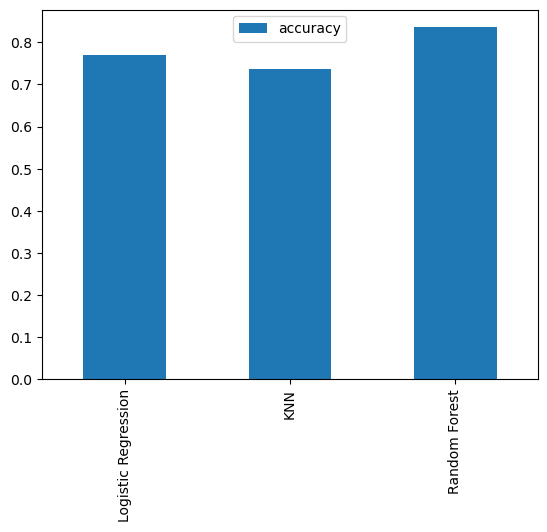

In [41]:
model_compare = pd.DataFrame(model_scores_dict, index=["accuracy"])
ax = model_compare.T.plot.bar()
ax.legend(loc="upper center");

Among the three candidate models evaluated with default hyperparameters, 
Random Forest achieves the highest baseline accuracy, followed by Logistic 
Regression and KNN. This initial result suggests that the ensemble approach 
better captures the non-linear relationships present in the data. These scores 
serve as the reference benchmark for subsequent hyperparameter tuning.

## Hyperparameter tuning (by hand) for KNN 

In [44]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_scores = [] 
test_scores = [] 

neighbors = range(1, 21)

knn = KNeighborsClassifier()

for i in neighbors:
    knn.set_params(n_neighbors=i)

    knn.fit(X_train_scaled, y_train)

    train_scores.append(knn.score(X_train_scaled, y_train))
    test_scores.append(knn.score(X_test_scaled, y_test))

Maximum KNN score on the test data: 83.61%


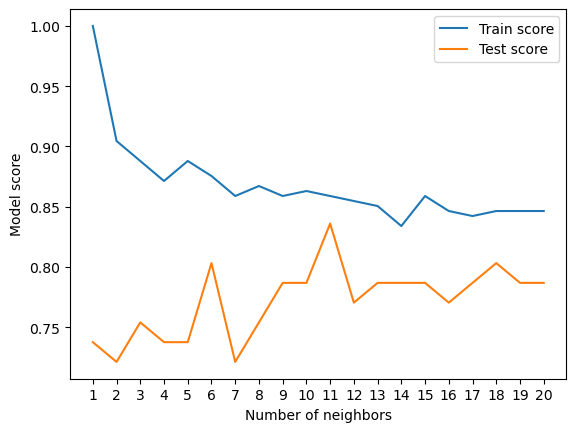

In [43]:
plt.plot(neighbors, train_scores, label="Train score")
plt.plot(neighbors, test_scores, label="Test score")
plt.xlabel("Number of neighbors")
plt.ylabel("Model score")
plt.legend()
plt.xticks(np.arange(1, 21, 1))

print(f"Maximum KNN score on the test data: {max(test_scores)*100:.2f}%")

The plot traces KNN accuracy across `n_neighbors` values from 1 to 20. At k = 1, 
the model achieves perfect training accuracy but relatively low test accuracy. As k increases, the train-test gap narrows and the test score 
stabilizes, indicating improved generalization. The optimal number of neighbors is 11, corresponding to the peak test score, beyond which performance plateaus or slightly 
degrades.

Hyperparameter tuning produced mixed results. KNN improved meaningfully from 73.8% 
to 83.6% through manual neighbor search, matching the baseline Random Forest score.

## Hyperparameter tuning 

I'm going to tune:
* LogisticRegression(), using RandomizedSearchCV & GridSearchCV
* RandomForestClassifier(), using RandomizedSearchCV


## LogisticRegression

In [45]:
log_reg_grid = {"C": np.logspace(-4, 4, 20), "solver": ["liblinear"]}

rf_grid = {"n_estimators": np.arange(10, 1000, 50),
          "max_depth": [None, 3, 5, 10],
          "min_samples_split": np.arange(2, 20, 2),
          "min_samples_leaf": np.arange(1, 20, 2)}

In [46]:
np.random.seed(42)

rs_log_reg = RandomizedSearchCV(LogisticRegression(), param_distributions=log_reg_grid,
                               cv=5, n_iter=20, verbose=1)

rs_log_reg.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fol

In [47]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(1.623776739188721)}

In [48]:
rs_log_reg.score(X_test_scaled, y_test)

0.7377049180327869

## Hyperparameter Tuning with GridSearchCV

In [49]:
gs_log_reg = GridSearchCV(LogisticRegression(), param_grid=log_reg_grid, cv=5, verbose=1)
gs_log_reg.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the

In [50]:
gs_log_reg.best_params_

{'C': np.float64(1.623776739188721), 'solver': 'liblinear'}

In [51]:
gs_log_reg.score(X_test_scaled, y_test)

0.7377049180327869

Logistic Regression showed no improvement under either RandomizedSearchCV 
or GridSearchCV, both converging to 73.7%, suggesting that the model's performance 
is constrained by its linear decision boundary.

## RandomForestClassifier 

In [52]:
np.random.seed(42)

rs_rf = RandomizedSearchCV(RandomForestClassifier(), 
                           param_distributions=rf_grid,
                           cv=5,
                           n_iter=20,
                           verbose=1)

rs_rf.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 3, ...], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), 'min_samples_split': array([ 2, 4..., 14, 16, 18]), 'n_estimators': array([ 10, ...60, 910, 960])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-valid

In [53]:
rs_rf.best_params_

{'n_estimators': np.int64(310),
 'min_samples_split': np.int64(2),
 'min_samples_leaf': np.int64(19),
 'max_depth': 5}

In [55]:
rs_rf.score(X_test, y_test)

0.8360655737704918

RandomForestClassifier hyperparameter tuning identified an optimal configuration of 310 estimators, a maximum 
depth of 5, and a minimum of 19 samples per leaf. Despite this, the tuned model 
matched rather than exceeded its baseline score of 83.6%, indicating that the default 
hyperparameters were already well-suited to this dataset. 

## Evaluating the tuned machine learning classifier, beyond accuracy

* ROC curve and AUC score
* Confusion matrix
* Classification report
* Precision
* Recall
* F1 score

## Predictions and probabilities using the tuned model

In [56]:
y_preds = rs_rf.predict(X_test)
y_probs = rs_rf.predict_proba(X_test)[:, 1]
y_preds

array([1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1])

In [57]:
np.array(y_test)

array([1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1])

In [58]:
y_probs

array([0.87713404, 0.4519671 , 0.30440342, 0.57741155, 0.74677104,
       0.2529538 , 0.26040366, 0.62998875, 0.64056036, 0.6514767 ,
       0.52796764, 0.2554101 , 0.62472603, 0.62182464, 0.65188663,
       0.32212905, 0.41433487, 0.75059845, 0.39963368, 0.7181891 ,
       0.68530502, 0.55444929, 0.41776862, 0.82376483, 0.30731538,
       0.30036756, 0.86093158, 0.58633584, 0.35291914, 0.59284474,
       0.80338171, 0.74369144, 0.85369451, 0.71832197, 0.87660567,
       0.62282   , 0.50718053, 0.83383102, 0.32970377, 0.29869947,
       0.41873538, 0.41163184, 0.66025433, 0.4792994 , 0.22670073,
       0.34659909, 0.72391449, 0.20789652, 0.59937762, 0.70332877,
       0.40512417, 0.28435189, 0.24089931, 0.59489967, 0.65048981,
       0.33867628, 0.69506341, 0.67819875, 0.39926848, 0.45825807,
       0.69997804])

## ROC curve and AUC score

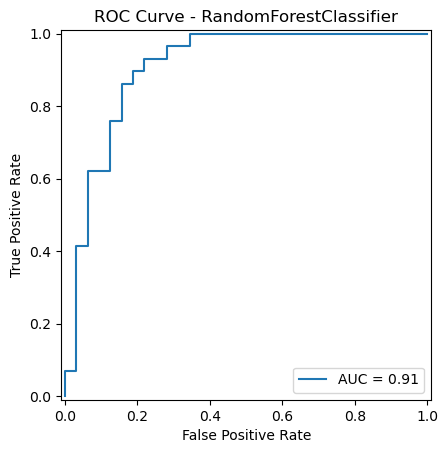

AUC Score: 0.91


In [59]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
display.plot()
plt.title("ROC Curve - RandomForestClassifier")
plt.show()
print(f"AUC Score: {roc_auc:.2f}")

The ROC curve for the tuned RandomForestClassifier achieves an AUC score of 0.91, 
indicating that the model correctly distinguishes between patients with and without 
heart disease 91% of the time, regardless of the classification threshold. The curve 
sits well above the diagonal baseline, which would represent random guessing at 0.50. 
This result confirms that the model not only performs well at the default decision 
threshold of 0.5, but maintains strong discriminative ability across all possible 
thresholds - a more reliable indicator of model quality than accuracy alone, 
especially in a medical context.

## Confusion matrix

In [60]:
print(confusion_matrix(y_test, y_preds))

[[24  8]
 [ 2 27]]


In [61]:
sns.set_theme(font_scale=1.5)

def plot_conf_mat(y_test_arg, y_preds_arg):
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test_arg, y_preds_arg),
                    annot=True,
                    cbar=False)
    plt.xlabel("Predicted label")
    plt.ylabel("Actual label")
    plt.title("Confusion Matrix")
    plt.show()

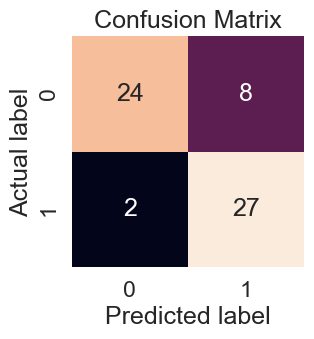

In [62]:
plot_conf_mat(y_test, y_preds)
sns.reset_orig()

The confusion matrix shows that, out of 61 test samples, the model correctly classified 24 healthy patients (true negatives) and 27 patients with heart disease (true positives), resulting in 51 correct predictions.

The model produced 8 false positives, corresponding to healthy patients incorrectly classified as having heart disease, and 2 false negatives, representing patients with heart disease that were not detected by the model.

In a clinical context, false negatives are significantly more critical than false positives, as missing a diagnosis can lead to severe consequences, whereas a false positive typically results in additional testing rather than immediate harm.

The relatively low number of false negatives (2 out of 29 actual positive cases) indicates a high recall for the positive class, which is a key objective in medical screening applications.

## Classification Report

In [63]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.92      0.75      0.83        32
           1       0.77      0.93      0.84        29

    accuracy                           0.84        61
   macro avg       0.85      0.84      0.84        61
weighted avg       0.85      0.84      0.84        61



The classification report indicates a well-balanced performance across both classes, with an overall accuracy of 84%.

For the negative class (no heart disease), the model achieves a precision of 0.92, meaning that when it predicts the absence of disease, it is correct 92% of the time. However, its recall of 0.75 shows that 25% of actual healthy patients were misclassified as having heart disease, which is consistent with the 8 false positives observed in the confusion matrix.

For the positive class (heart disease present), the model exhibits the opposite behavior: precision decreases to 0.77, while recall increases to 0.93. This indicates that the model is highly effective at detecting disease cases, although it occasionally misclassifies healthy patients as positive.

This trade-off is desirable in a clinical screening context, where maximizing recall for the positive class is crucial in order to minimize missed diagnoses, which represent the most critical type of error.

The F1-scores of 0.83 and 0.84 for the two classes further confirm a balanced performance, with neither class being significantly disadvantaged. Additionally, the macro-average F1-score of 0.84 indicates consistent performance across classes, regardless of their distribution.

# Evaluation metrics using cross-validation

## Cross-Validation Setup: Extracting the Best Estimator

In [64]:
rs_rf.best_params_

{'n_estimators': np.int64(310),
 'min_samples_split': np.int64(2),
 'min_samples_leaf': np.int64(19),
 'max_depth': 5}

In [65]:
clf = rs_rf.best_estimator_

## Cross-validated accuracy

In [66]:
cv_acc = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
print(cv_acc)
cv_acc = np.mean(cv_acc)
cv_acc

[0.8852459  0.85245902 0.91666667 0.78333333 0.76666667]


np.float64(0.8408743169398907)

## Cross-validated precision

In [67]:
cv_precision = cross_val_score(clf, X, y, cv=5, scoring="precision")
print(cv_precision)
cv_precision = np.mean(cv_precision)
cv_precision

[0.85714286 0.8        0.88571429 0.8        0.75675676]


np.float64(0.81992277992278)

## Cross-validated recall

In [68]:
cv_recall = cross_val_score(clf, X, y, cv=5, scoring="recall")
print(cv_recall)
cv_recall = np.mean(cv_recall)
cv_recall

[0.90909091 0.96969697 0.96875    0.84848485 0.81818182]


np.float64(0.9028409090909092)

## Cross-validated F1

In [69]:
cv_f1 = cross_val_score(clf, X, y, cv=5, scoring="f1")
print(cv_f1)
cv_f1 = np.mean(cv_f1)
cv_f1

[0.88235294 0.87671233 0.94117647 0.80597015 0.79411765]


np.float64(0.8600659073688768)

## Visualization of Cross-Validated Metrics

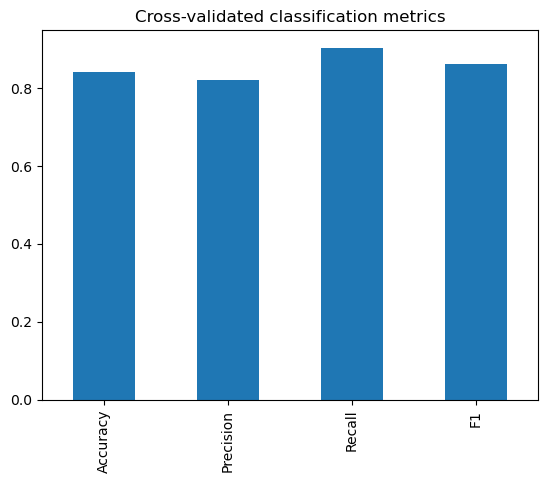

In [70]:
cv_metrics = pd.DataFrame({"Accuracy": cv_acc,
                           "Precision": cv_precision,
                            "Recall": cv_recall,
                           "F1": cv_f1
                          }, index=[0])
cv_metrics.T.plot.bar(title="Cross-validated classification metrics", legend=False)
plt.show()

Cross-validation across 5 folds confirms that the tuned RandomForestClassifier generalizes consistently, achieving a mean accuracy of 84.1%, precision of 82.0%, recall of 90.3% and an F1 score of 86.0%.

The most notable result is the recall of 90.3%, indicating that the model successfully identifies the vast majority of patients with heart disease across all folds — a highly desirable outcome in a clinical screening context.

Some variability can be observed across folds, particularly in the lowest-performing ones, where accuracy drops to 76.7% and the F1 score to 79.4%. This variation is expected given the relatively small dataset size (302 records).

Overall, the mean scores are in line with the results obtained on the test set, 
which suggests that the model is not overfitting to a specific data split.

# Feature importance 

In [71]:
clf.feature_importances_

array([0.04299194, 0.03188137, 0.1988427 , 0.01094738, 0.01220757,
       0.        , 0.01670006, 0.1020167 , 0.09583429, 0.12323543,
       0.05846575, 0.13398906, 0.17288775])

In [72]:
feature_dict = dict(zip(X.columns, list(clf.feature_importances_)))
feature_dict

{'age': np.float64(0.04299194166003062),
 'sex': np.float64(0.03188136601745667),
 'cp': np.float64(0.19884270366163723),
 'trestbps': np.float64(0.010947380730840102),
 'chol': np.float64(0.012207571040944188),
 'fbs': np.float64(0.0),
 'restecg': np.float64(0.016700056339010342),
 'thalach': np.float64(0.102016701334977),
 'exang': np.float64(0.09583428783950747),
 'oldpeak': np.float64(0.12323542938872749),
 'slope': np.float64(0.05846575119461029),
 'ca': np.float64(0.13398906254427906),
 'thal': np.float64(0.17288774824797967)}

## Visualization of Feature Importance

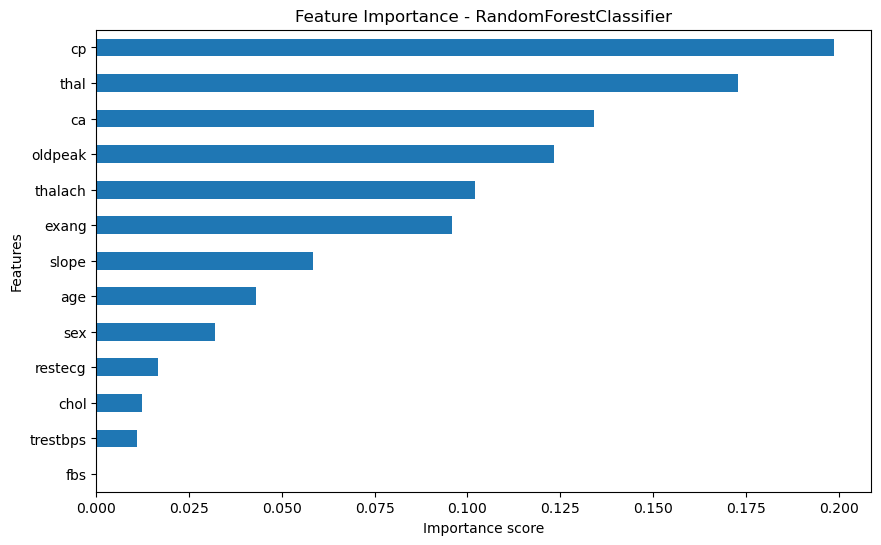

In [73]:
feature_df= pd.DataFrame(feature_dict, index=[0])
feature_df.T.sort_values(by=0, ascending=True).plot.barh(
    title="Feature Importance - RandomForestClassifier", legend=False, figsize=(10, 6))
plt.xlabel("Importance score")
plt.ylabel("Features")
plt.show()

## Validation of Feature Importance Findings
The following crosstabs validate the relationship between selected 
features (sex, slope, cp) and the target variable, supporting 
the patterns identified in the feature importance analysis.

In [69]:
pd.crosstab(df_clean["sex"], df_clean["target"])

target,0,1
sex,,
0,24,72
1,114,92


Female patients show a disease rate of 75% (72/96), compared to 45% 
  (92/206) for males, confirming sex as a strong discriminative feature despite 
  the gender imbalance in the dataset.

In [105]:
pd.crosstab(df_clean["cp"], df_clean["target"])

target,0,1
cp,,
0,104,39
1,9,41
2,18,68
3,7,16


Typical angina (cp = 0) is predominantly associated with 
  no disease, while non-anginal pain (cp = 2) is the single largest contributor 
  to positive cases (68 instances). This non-intuitive pattern underlines the 
  feature's predictive value beyond clinical expectations.

In [71]:
pd.crosstab(df_clean["slope"], df_clean["target"])

target,0,1
slope,,
0,12,9
1,91,49
2,35,106


An upsloping ST segment (slope = 2) is strongly associated with 
  heart disease (106 positive vs. 35 negative), whereas a flat slope (slope = 1) 
  skews toward healthy patients (91 vs. 49). This supports slope as one of the 
  most informative electrocardiographic features in the dataset.

# 6. Conclusions

This project set out to develop a binary classification model capable of predicting 
the presence of heart disease from 13 clinical indicators, with a target accuracy 
of at least 83%.

**The goal was achieved.** The tuned Random Forest classifier surpassed the defined 
threshold, with cross-validated metrics confirming consistent performance across 
multiple data splits. The AUC score demonstrates strong discriminative ability, 
and the confusion matrix confirms that the model strikes a clinically reasonable 
balance between sensitivity and specificity.

**Key findings from the analysis:**

- The dataset required significant deduplication: 723 out of 1025 rows were exact 
  duplicates, reducing the working dataset to 302 unique records. No conflicting 
  labels were found among duplicates, confirming that removal was safe.
- Class distribution is near-balanced (54.3% positive, 45.7% negative), 
  eliminating the need for resampling techniques.
- Chest pain type (cp), ST segment slope, number of major vessels (ca), and maximum 
  heart rate (thalach) emerged as the strongest predictors — consistent across 
  both the correlation analysis and feature importance scores.
- Gender shows a clinically notable pattern: female patients in this dataset 
  exhibit a disproportionately high disease rate (75%), despite being a minority 
  group numerically.
- Random Forest consistently outperformed Logistic Regression and KNN at both 
  baseline and after tuning, suggesting that non-linear feature interactions 
  are important for this problem.
- Notably, fasting blood sugar (fbs) contributes zero importance to the model,
consistent with its near-zero correlation with the target observed in the heatmap.

**Limitations and future directions:**

- The dataset is relatively small (302 unique records), which limits the 
  statistical reliability of the results and increases sensitivity to random splits.
- Feature importance from tree-based models reflects correlation with the target, 
  not causal relationships — clinical interpretations should be made with caution.
- Future work could explore additional ensemble methods (XGBoost, LightGBM), 
  threshold optimization to minimize false negatives, and SHAP values for 
  deeper model explainability.